In [3]:
import os

count = 0

for dirname, dirs, files in os.walk('/kaggle/input'):
    print(f"\nDirectory: {dirname}")

    for file in files[:10]:
        print("  ", file)

    count += 1
    if count >= 20:
        break


Directory: /kaggle/input

Directory: /kaggle/input/datasets

Directory: /kaggle/input/datasets/splcher

Directory: /kaggle/input/datasets/splcher/animefacedataset

Directory: /kaggle/input/datasets/splcher/animefacedataset/images
   35715_2011.jpg
   48610_2014.jpg
   34719_2011.jpg
   40266_2012.jpg
   4199_2002.jpg
   40739_2013.jpg
   42515_2013.jpg
   52482_2015.jpg
   46555_2014.jpg
   11579_2005.jpg


In [4]:
import os
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),
                         (0.5,0.5,0.5))
])

class AnimeDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.images = [
            os.path.join(root_dir, img)
            for img in os.listdir(root_dir)
            if img.endswith((".jpg", ".png", ".jpeg"))
        ]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image

dataset_path = "/kaggle/input/datasets/splcher/animefacedataset/images"

dataset = AnimeDataset(
    root_dir=dataset_path,
    transform=transform
)

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

print("Total Images:", len(dataset))

Total Images: 63565


In [5]:
sample = next(iter(loader))

print(sample.shape)

torch.Size([64, 3, 64, 64])


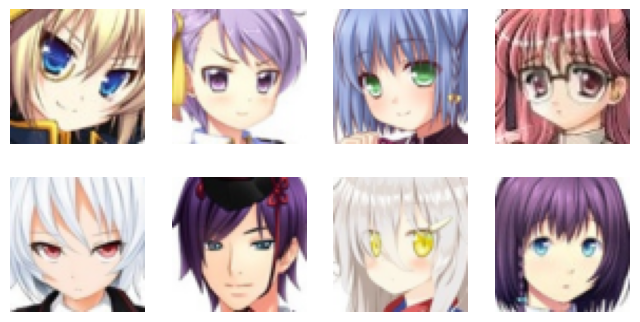

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(8,4))

for i, ax in enumerate(axes.flatten()):
    img = sample[i]

    img = img.permute(1,2,0)

    img = (img + 1) / 2

    ax.imshow(img)
    ax.axis("off")

plt.show()

In [7]:
import torch.nn as nn

latent_dim = 100

class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(True),

            nn.Linear(256, 512),
            nn.ReLU(True),

            nn.Linear(512, 1024),
            nn.ReLU(True),

            nn.Linear(1024, 64 * 64 * 3),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(-1, 3, 64, 64)
        return img

In [8]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(64 * 64 * 3, 1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        img = img.view(img.size(0), -1)
        validity = self.model(img)
        return validity

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

generator = Generator().to(device)
discriminator = Discriminator().to(device)

print(device)

cuda


In [10]:
noise = torch.randn(4, latent_dim).to(device)

fake_images = generator(noise)

print(fake_images.shape)

torch.Size([4, 3, 64, 64])


In [11]:
criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(
    generator.parameters(),
    lr=0.0002
)

optimizer_D = torch.optim.Adam(
    discriminator.parameters(),
    lr=0.0002
)

In [12]:
epochs = 5

for epoch in range(epochs):

    for real_imgs in loader:

        real_imgs = real_imgs.to(device)

        batch_size = real_imgs.size(0)

        real_labels = torch.ones(
            batch_size, 1
        ).to(device)

        fake_labels = torch.zeros(
            batch_size, 1
        ).to(device)

        # Train Discriminator

        optimizer_D.zero_grad()

        real_output = discriminator(real_imgs)

        d_real_loss = criterion(
            real_output,
            real_labels
        )

        noise = torch.randn(
            batch_size,
            latent_dim
        ).to(device)

        fake_imgs = generator(noise)

        fake_output = discriminator(
            fake_imgs.detach()
        )

        d_fake_loss = criterion(
            fake_output,
            fake_labels
        )

        d_loss = d_real_loss + d_fake_loss

        d_loss.backward()

        optimizer_D.step()

        # Train Generator

        optimizer_G.zero_grad()

        noise = torch.randn(
            batch_size,
            latent_dim
        ).to(device)

        fake_imgs = generator(noise)

        output = discriminator(fake_imgs)

        g_loss = criterion(
            output,
            real_labels
        )

        g_loss.backward()

        optimizer_G.step()

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"D Loss: {d_loss.item():.4f} "
        f"G Loss: {g_loss.item():.4f}"
    )

Epoch [1/5] D Loss: 0.0000 G Loss: 100.0000
Epoch [2/5] D Loss: 0.0000 G Loss: 100.0000
Epoch [3/5] D Loss: 0.0000 G Loss: 100.0000
Epoch [4/5] D Loss: 0.0000 G Loss: 100.0000
Epoch [5/5] D Loss: 0.0000 G Loss: 100.0000


In [13]:
noise = torch.randn(16, latent_dim).to(device)

with torch.no_grad():
    generated = generator(noise)

generated = generated.cpu()

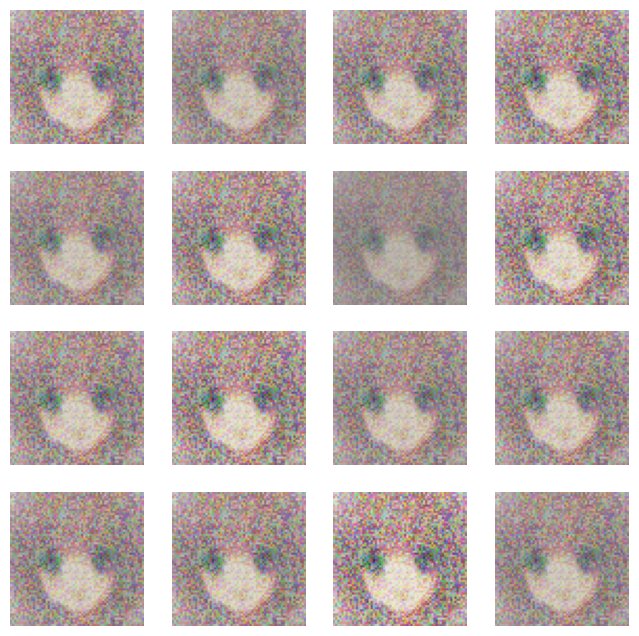

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 4, figsize=(8,8))

for i, ax in enumerate(axes.flatten()):

    img = generated[i]

    img = img.permute(1,2,0)

    img = (img + 1) / 2

    ax.imshow(img)

    ax.axis("off")

plt.savefig("vanilla_gan_generated_samples.png")
plt.show()